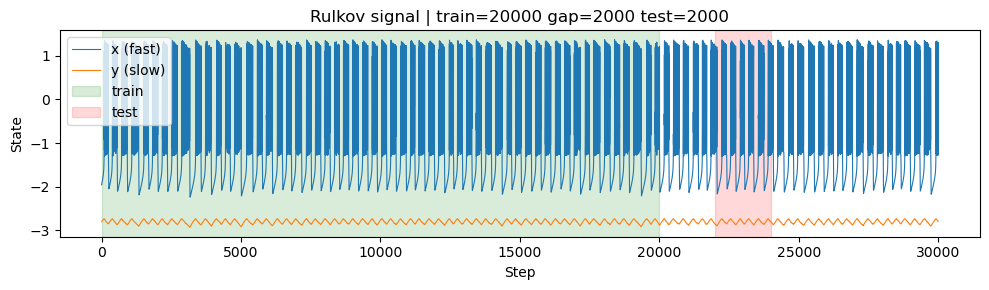


multiscale grid: 3375 configs x 3 seeds = 10125 evaluations


In [ ]:
"""
Multi-Scale RFF-RC for Rulkov map — closed-loop grid search, upgraded.

Upgrades over the basic paper implementation:
  1. Composite scoring: short-horizon NRMSE + log spike-count penalty.
     NRMSE saturates on chaotic rollouts; spike count measures attractor
     fidelity. Combination gives a useful ranking metric.
  2. Residual prediction: target is (x_{n+1} - x_n, y_{n+1} - y_n). Frees
     the readout from memorizing the near-identity slow-variable map,
     which dominates Rulkov because mu = 0.001.
  3. Per-variable ridge: separate lambda_x, lambda_y. Signal statistics
     differ by orders of magnitude between x (spikes) and y (drift); one
     lambda is wrong for both.
  4. NG-RC style raw concatenation: concat phi(u) with u itself. Gives
     the readout direct linear access to inputs while preserving RFF
     expressiveness for nonlinear terms.
  5. Training noise injection: add Gaussian noise to scaled delay inputs
     at ridge-fit time. Acts as scheduled-sampling-lite, teaching the
     readout to handle noisy inputs like those encountered at rollout.
  6. Multiple short rollouts: rather than a single 1000-step rollout,
     start K rollouts from K evenly-spaced real delay vectors across the
     test segment. Median VPT / composite across rollouts.
  7. Train/test gap: no fading memory in this model, but a gap still
     cleans up the test as an independent chunk of the attractor.

Hyperparameter priority:
  HIGHEST: sigma_x, sigma_y        (multi-scale mechanism)
  HIGH:    ridge_alpha_x, _y       (closed-loop stability)
  HIGH:    noise_sigma             (generalization of train -> rollout)
  MEDIUM:  lag                     (Rulkov is 2D Markov; L=1 viable)
  LOW:     D_x, D_y                (fixed at 1000 each)
"""

import numpy as np
import matplotlib.pyplot as plt
import itertools
import time

from sklearn.linear_model import Ridge

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../..')))
from lib.utils.reservoirpy import (
    fit_scaler, transform_array, inverse_transform_array
)


# ==========================================================
# FIXED PARAMETERS
# ==========================================================
FIXED = {
    "train_len":       20000,
    "gap_len":         2000,
    "test_len":        2000,
    "rollout_len":     1500,   # each rollout length
    "n_rollouts":      5,      # evenly spaced start points inside test
    "tracking_horizon": 50,    # matches user's other-model protocol
    "spike_threshold": 0.0,
    "spike_weight":    0.5,
    "normalization":   "minmax11",
    "D_x":             1000,
    "D_y":             1000,
    "seed_list":       [42, 7, 2024],   # matches user's other-model protocol
    "top_k":           10,
    "vpt_threshold":   0.4,
    "use_residual":    True,
    "use_raw_concat":  True,
}

# train_start = 0
# train ends at FIXED["train_len"]
# test starts at train_len + gap_len
TRAIN_START = 0
TRAIN_END   = FIXED["train_len"]
TEST_START  = FIXED["train_len"] + FIXED["gap_len"]
TEST_END    = TEST_START + FIXED["test_len"]


# ==========================================================
# GRID
# ==========================================================
# Denser than paper-faithful grid because we've added two new axes
# (ridge_alpha_x/y split, noise_sigma). Keep sigma_x/y dense since they
# remain the single most important parameter pair.
GRID = {
    "lag":           [1, 2, 4, 8, 16],
    "sigma_x":       [0.03, 0.1, 0.3, 1.0, 3.0],
    "sigma_y":       [0.1, 1.0, 3.0, 10.0, 30.0],
    "ridge_alpha_x": [1e-10, 1e-7, 1e-4],
    "ridge_alpha_y": [1e-10, 1e-7, 1e-4],
    "noise_sigma":   [0.0, 0.001, 0.005],
}

GRID_SINGLE = {
    "lag":           [2, 4, 8, 16],
    "sigma_single":  [0.1, 0.3, 1.0, 3.0, 10.0],
    "ridge_alpha_x": [1e-10, 1e-7, 1e-4],
    "ridge_alpha_y": [1e-10, 1e-7, 1e-4],
    "noise_sigma":   [0.0, 0.001, 0.005],
    "D_total":       [2000],
}

COMPARE_SINGLE_SCALE = True


# ==========================================================
# DATA LOADING
# ==========================================================
dataset = np.loadtxt('../../../data/chaotic_data/rulkov_map.csv', delimiter=',')
if dataset.ndim == 1:
    dataset = dataset.reshape(-1, 1)
if dataset.shape[1] >= 2:
    dataset = dataset[:, :2]
if dataset.shape[1] < 2:
    raise RuntimeError("Expect 2-variable Rulkov data [x, y].")

required_len = TEST_END + 1
if len(dataset) < required_len:
    raise RuntimeError(
        f"Need at least {required_len} points; got {len(dataset)}. "
        "Increase your Rulkov simulation length."
    )

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset[:, 0], linewidth=0.8, label='x (fast)')
ax.plot(dataset[:, 1], linewidth=0.8, label='y (slow)')
ax.axvspan(TRAIN_START, TRAIN_END, alpha=0.15, color='green', label='train')
ax.axvspan(TEST_START, TEST_END, alpha=0.15, color='red', label='test')
ax.legend(); ax.set_xlabel("Step"); ax.set_ylabel("State")
ax.set_title(f"Rulkov signal | train={FIXED['train_len']} gap={FIXED['gap_len']} test={FIXED['test_len']}")
plt.tight_layout(); plt.show()


# ==========================================================
# CORE FUNCTIONS
# ==========================================================
def build_delay_embedding_multivar(data, lag):
    """Layout: [x_t, x_{t-1}, ..., x_{t-lag+1}, y_t, ..., y_{t-lag+1}]"""
    T, n_vars = data.shape
    X, Y = [], []
    for t in range(lag, T):
        row = [data[t - lag:t, j][::-1] for j in range(n_vars)]
        X.append(np.concatenate(row))
        Y.append(data[t])
    return np.asarray(X), np.asarray(Y)


def most_recent_from_delay(delay_vec, n_vars, lag):
    """Extract [x_t, y_t] from a delay vector — the most recent values."""
    return np.array([delay_vec[j * lag] for j in range(n_vars)])


def rff_map(X, W, b):
    D = W.shape[1]
    return np.sqrt(2.0 / D) * np.cos(X @ W + b)


class MultiScaleRFFReservoir:
    def __init__(self, lag, n_vars, D_per_var, sigmas, rng_seed=42,
                 use_raw_concat=False):
        self.lag = lag
        self.n_vars = n_vars
        self.use_raw_concat = use_raw_concat
        rng = np.random.RandomState(rng_seed)
        self.W_blocks, self.b_blocks = [], []
        for j in range(n_vars):
            D = int(D_per_var[j]); sigma = float(sigmas[j])
            self.W_blocks.append(
                rng.normal(loc=0.0, scale=1.0 / sigma, size=(lag, D))
            )
            self.b_blocks.append(rng.uniform(0.0, 2.0 * np.pi, size=D))

    def transform(self, X_delay):
        feats = []
        for j in range(self.n_vars):
            s, e = j * self.lag, (j + 1) * self.lag
            feats.append(rff_map(X_delay[:, s:e],
                                 self.W_blocks[j], self.b_blocks[j]))
        phi = np.hstack(feats)
        if self.use_raw_concat:
            phi = np.hstack([phi, X_delay])
        return phi


class SingleScaleRFFReservoir:
    def __init__(self, input_dim, D_total, sigma, rng_seed=42,
                 use_raw_concat=False):
        self.use_raw_concat = use_raw_concat
        rng = np.random.RandomState(rng_seed)
        self.W = rng.normal(loc=0.0, scale=1.0 / sigma,
                            size=(input_dim, D_total))
        self.b = rng.uniform(0.0, 2.0 * np.pi, size=D_total)

    def transform(self, X_delay):
        phi = rff_map(X_delay, self.W, self.b)
        if self.use_raw_concat:
            phi = np.hstack([phi, X_delay])
        return phi


def update_delay_vector(delay_vec, pred, n_vars, lag):
    out = delay_vec.copy()
    for j in range(n_vars):
        s, e = j * lag, (j + 1) * lag
        block = out[s:e]
        block[1:] = block[:-1]
        block[0]  = pred[j]
        out[s:e] = block
    return out


# ==========================================================
# METRICS
# ==========================================================
def count_spikes(signal, threshold=0.0):
    s = np.asarray(signal).ravel()
    is_peak = (s[1:-1] > s[:-2]) & (s[1:-1] > s[2:]) & (s[1:-1] > threshold)
    return int(np.sum(is_peak))


def nrmse_per_var(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
    denom = np.std(y_true, axis=0)
    denom = np.where(denom == 0, 1.0, denom)
    return rmse / denom


def valid_prediction_time(y_true, y_pred, threshold=0.4):
    scale = np.std(y_true, axis=0)
    scale = np.where(scale == 0, 1.0, scale)
    err = np.abs(y_true - y_pred) / scale
    bad = np.where(err.max(axis=1) > threshold)[0]
    return int(bad[0]) if len(bad) > 0 else len(y_true)


def spike_penalty(y_true_x, y_pred_x, threshold=0.0):
    n_true = count_spikes(y_true_x, threshold)
    n_pred = count_spikes(y_pred_x, threshold)
    if n_true == 0 and n_pred == 0: return 0.0
    if n_true == 0 or n_pred == 0:  return 5.0
    return float(abs(np.log(n_pred / n_true)))


def composite_score(y_true, y_pred, horizon, spike_threshold, spike_weight):
    h = min(horizon, len(y_true))
    tracking = float(np.mean(nrmse_per_var(y_true[:h], y_pred[:h])))
    attractor = spike_penalty(y_true[:, 0], y_pred[:, 0], spike_threshold)
    return tracking + spike_weight * attractor, tracking, attractor


def is_diverged(y_pred):
    return (not np.all(np.isfinite(y_pred))) or np.max(np.abs(y_pred)) > 1e4


# ==========================================================
# EVALUATION — CLOSED-LOOP with all upgrades
# ==========================================================
def evaluate_closed_loop(
    data,
    mode, lag,
    ridge_alpha_x, ridge_alpha_y, noise_sigma,
    sigma_x=None, sigma_y=None, D_x=None, D_y=None,
    sigma_single=None, D_total=None,
    normalization="minmax11",
    train_start=0, train_end=4000,
    test_start=4500, test_end=6500,
    rollout_len=1500, n_rollouts=5,
    rng_seed=42,
    vpt_threshold=0.4,
    tracking_horizon=100,
    spike_threshold=0.0, spike_weight=0.5,
    use_residual=True, use_raw_concat=True,
):
    try:
        # Build embedding on the full data, then slice.
        X_raw_all, Y_raw_all = build_delay_embedding_multivar(data, lag)
        # Index offsets: embedding drops the first `lag` points.
        X_train_raw = X_raw_all[train_start:train_end]
        Y_train_raw = Y_raw_all[train_start:train_end]
        X_test_raw  = X_raw_all[test_start:test_end]
        Y_test_raw  = Y_raw_all[test_start:test_end]
        if len(X_train_raw) == 0 or len(X_test_raw) < rollout_len:
            return None

        n_vars = Y_raw_all.shape[1]

        # Residual targets: Delta_n = x_{n+1} - x_n
        # (x_n is the most recent entry in the delay vector for each var)
        if use_residual:
            X_most_recent_train = np.stack([
                X_train_raw[:, j * lag] for j in range(n_vars)
            ], axis=1)
            X_most_recent_test = np.stack([
                X_test_raw[:, j * lag] for j in range(n_vars)
            ], axis=1)
            T_train_raw = Y_train_raw - X_most_recent_train   # residual targets
            T_test_raw  = Y_test_raw  - X_most_recent_test
        else:
            T_train_raw = Y_train_raw
            T_test_raw  = Y_test_raw

        # Scalers fit on training segments only.
        x_scaler = fit_scaler(X_train_raw, method=normalization)
        t_scaler = fit_scaler(T_train_raw, method=normalization)
        # We still need a y_scaler for metric reporting in original scale.
        y_scaler = fit_scaler(Y_train_raw, method=normalization)

        X_train = transform_array(X_train_raw, x_scaler)
        T_train = transform_array(T_train_raw, t_scaler)
        X_test  = transform_array(X_test_raw,  x_scaler)
        # We don't transform Y_test through t_scaler — we compare in raw units.

        # Training noise injection (scaled domain).
        rng_noise = np.random.RandomState(rng_seed + 1000)
        if noise_sigma > 0:
            X_train_noisy = X_train + rng_noise.normal(
                scale=noise_sigma, size=X_train.shape
            )
        else:
            X_train_noisy = X_train

        # Build reservoir.
        if mode == "multiscale":
            reservoir = MultiScaleRFFReservoir(
                lag=lag, n_vars=n_vars,
                D_per_var=[D_x, D_y], sigmas=[sigma_x, sigma_y],
                rng_seed=rng_seed, use_raw_concat=use_raw_concat,
            )
        elif mode == "singlescale":
            reservoir = SingleScaleRFFReservoir(
                input_dim=X_train.shape[1],
                D_total=D_total, sigma=sigma_single,
                rng_seed=rng_seed, use_raw_concat=use_raw_concat,
            )
        else:
            raise ValueError(mode)

        # Train two independent ridge readouts, one per variable.
        F_train = reservoir.transform(X_train_noisy)
        readout_x = Ridge(alpha=ridge_alpha_x).fit(F_train, T_train[:, 0])
        readout_y = Ridge(alpha=ridge_alpha_y).fit(F_train, T_train[:, 1])

        # ---- Closed-loop rollouts from K evenly-spaced test-segment starts ----
        # We pick K start indices inside X_test that still leave room for a
        # full rollout_len inside the test segment (or inside the embedded
        # array). Use Y_raw_all as ground truth to allow rollout to extend
        # beyond the initial X_test window.
        test_abs_start = test_start  # index into X_raw_all
        max_start = test_end - rollout_len
        if max_start <= test_abs_start:
            starts = [test_abs_start]
        else:
            starts = np.linspace(test_abs_start, max_start,
                                 n_rollouts, dtype=int).tolist()

        per_rollout = []
        for s_idx in starts:
            init_delay_raw = X_raw_all[s_idx].copy()
            init_delay = transform_array(
                init_delay_raw.reshape(1, -1), x_scaler
            )[0]

            pred_len = rollout_len
            Y_pred_raw = np.zeros((pred_len, n_vars))
            Y_true_raw = Y_raw_all[s_idx:s_idx + pred_len]
            current = init_delay.copy()

            for k in range(pred_len):
                feat = reservoir.transform(current.reshape(1, -1))
                # Predicted residual (scaled domain)
                pred_t_scaled = np.array([
                    readout_x.predict(feat)[0],
                    readout_y.predict(feat)[0],
                ])
                # Inverse-scale residual to raw
                pred_t_raw = inverse_transform_array(
                    pred_t_scaled.reshape(1, -1), t_scaler
                )[0]
                # Reconstruct next raw state
                if use_residual:
                    x_now_raw = most_recent_from_delay(
                        inverse_transform_array(current.reshape(1, -1),
                                                x_scaler)[0],
                        n_vars, lag,
                    )
                    next_raw = x_now_raw + pred_t_raw
                else:
                    next_raw = pred_t_raw

                Y_pred_raw[k] = next_raw

                # Re-scale next_raw using per-variable params from x_scaler.
                # x_scaler was fit on the full delay vector; all `lag` columns
                # for variable j share the same scaling params, so reading
                # from column j*lag gives the right per-variable params.
                next_scaled = _rescale_new_point(next_raw, x_scaler,
                                                 n_vars, lag)
                current = update_delay_vector(current, next_scaled, n_vars, lag)

            diverged = is_diverged(Y_pred_raw)
            if diverged:
                Y_pred_raw = np.nan_to_num(Y_pred_raw, nan=0.0,
                                           posinf=1e4, neginf=-1e4)

            nrmse_vec = nrmse_per_var(Y_true_raw, Y_pred_raw)
            vpt = valid_prediction_time(Y_true_raw, Y_pred_raw,
                                        threshold=vpt_threshold)
            comp, track, atk = composite_score(
                Y_true_raw, Y_pred_raw,
                tracking_horizon, spike_threshold, spike_weight,
            )
            per_rollout.append({
                "start": s_idx, "diverged": diverged,
                "nrmse_mean": float(np.mean(nrmse_vec)),
                "nrmse_vec": nrmse_vec,
                "vpt": vpt, "composite": comp,
                "tracking": track, "spike_pen": atk,
                "Y_true": Y_true_raw, "Y_pred": Y_pred_raw,
            })

        any_diverged = any(r["diverged"] for r in per_rollout)
        composites = [r["composite"] for r in per_rollout]
        vpts = [r["vpt"] for r in per_rollout]
        nrmses = [r["nrmse_mean"] for r in per_rollout]

        # Pick a representative rollout (median composite) for plotting
        med_idx = int(np.argsort(composites)[len(composites) // 2])
        rep = per_rollout[med_idx]

        return {
            "mode": mode, "lag": lag,
            "ridge_alpha_x": ridge_alpha_x, "ridge_alpha_y": ridge_alpha_y,
            "noise_sigma": noise_sigma,
            "sigma_x": sigma_x, "sigma_y": sigma_y,
            "D_x": D_x, "D_y": D_y,
            "sigma_single": sigma_single, "D_total": D_total,
            "seed": rng_seed,
            "composite_median": float(np.median(composites)),
            "composite_max":    float(np.max(composites)),
            "vpt_median":       float(np.median(vpts)),
            "vpt_min":          int(np.min(vpts)),
            "nrmse_median":     float(np.median(nrmses)),
            "diverged":         bool(any_diverged),
            "rep_Y_true":       rep["Y_true"],
            "rep_Y_pred":       rep["Y_pred"],
            "rep_vpt":          rep["vpt"],
            "rep_composite":    rep["composite"],
            "rep_tracking":     rep["tracking"],
            "rep_spike_pen":    rep["spike_pen"],
            "n_vars":           n_vars,
        }
    except Exception as e:
        print(f"ERROR: {e}")
        return None


def _rescale_new_point(raw_point, x_scaler, n_vars, lag):
    """Scale a single [x, y] point using x_scaler's per-column params.

    x_scaler was fit on the concatenated delay vector of length lag*n_vars.
    For each variable j, columns [j*lag : (j+1)*lag] all share the same
    scaling params because they're all the same signal at different lags
    in the fit data. So we can read the j*lag column's params.
    """
    method = x_scaler["method"]
    out = np.zeros(n_vars)
    for j in range(n_vars):
        col = j * lag
        v = raw_point[j]
        if method == "zscore":
            out[j] = (v - x_scaler["mu"][col]) / x_scaler["sigma"][col]
        elif method == "minmax01":
            out[j] = (v - x_scaler["xmin"][col]) / x_scaler["span"][col]
        elif method == "minmax11":
            out[j] = 2.0 * (v - x_scaler["xmin"][col]) / x_scaler["span"][col] - 1.0
        elif method == "none":
            out[j] = v
        else:
            raise ValueError(method)
    return out


def _scale_delay_vector(delay_raw, x_scaler):
    """Scale a single delay vector using fit_scaler's transform."""
    return transform_array(delay_raw.reshape(1, -1), x_scaler)[0]


# ==========================================================
# GRID SEARCH
# ==========================================================
def make_combos(grid):
    keys = list(grid.keys())
    return keys, list(itertools.product(*[grid[k] for k in keys]))


def run_grid(data, grid, mode):
    """Grid search. Each config evaluated across all seeds in FIXED['seed_list'].
    Configs where any seed diverges are rejected (not included in results)."""
    keys, combos = make_combos(grid)
    n_seeds = len(FIXED["seed_list"])
    print(f"\n{mode} grid: {len(combos)} configs x {n_seeds} seeds "
          f"= {len(combos) * n_seeds} evaluations")
    results, t0 = [], time.time()
    rejected = 0
    for i, combo in enumerate(combos, 1):
        p = dict(zip(keys, combo))

        per_seed = []
        any_diverged = False
        for seed in FIXED["seed_list"]:
            common = dict(
                data=data, mode=mode, lag=p["lag"],
                ridge_alpha_x=p["ridge_alpha_x"],
                ridge_alpha_y=p["ridge_alpha_y"],
                noise_sigma=p["noise_sigma"],
                normalization=FIXED["normalization"],
                train_start=TRAIN_START, train_end=TRAIN_END,
                test_start=TEST_START, test_end=TEST_END,
                rollout_len=FIXED["rollout_len"],
                n_rollouts=FIXED["n_rollouts"],
                rng_seed=seed,
                vpt_threshold=FIXED["vpt_threshold"],
                tracking_horizon=FIXED["tracking_horizon"],
                spike_threshold=FIXED["spike_threshold"],
                spike_weight=FIXED["spike_weight"],
                use_residual=FIXED["use_residual"],
                use_raw_concat=FIXED["use_raw_concat"],
            )
            if mode == "multiscale":
                r = evaluate_closed_loop(
                    sigma_x=p["sigma_x"], sigma_y=p["sigma_y"],
                    D_x=FIXED["D_x"], D_y=FIXED["D_y"],
                    **common,
                )
            else:
                r = evaluate_closed_loop(
                    sigma_single=p["sigma_single"],
                    D_total=p["D_total"],
                    **common,
                )

            if r is None or r["diverged"]:
                any_diverged = True
                break
            per_seed.append(r)

        if any_diverged:
            rejected += 1
        else:
            # Aggregate across seeds: mean composite, min VPT (worst case)
            comps = [x["composite_median"] for x in per_seed]
            vpts  = [x["vpt_median"]       for x in per_seed]
            nrms  = [x["nrmse_median"]     for x in per_seed]
            # Use the median-composite seed for plotting
            med_seed_idx = int(np.argsort(comps)[len(comps) // 2])
            rep = per_seed[med_seed_idx]

            rec = dict(rep)  # carry over most fields
            rec.update({
                "composite_mean":  float(np.mean(comps)),
                "composite_worst": float(np.max(comps)),
                "vpt_mean":        float(np.mean(vpts)),
                "vpt_worst":       int(np.min(vpts)),
                "nrmse_mean":      float(np.mean(nrms)),
                "n_seeds":         len(per_seed),
            })
            results.append(rec)

        if i % 50 == 0 or i == len(combos):
            if results:
                best_c = min(x["composite_mean"] for x in results)
                best_v = max(x["vpt_mean"]       for x in results)
            else:
                best_c, best_v = np.inf, 0
            print(f"  [{mode} {i:5d}/{len(combos)}]  "
                  f"elapsed={time.time()-t0:7.1f}s  "
                  f"kept={len(results)}  rejected={rejected}  "
                  f"best_comp={best_c:.4f}  best_vpt={best_v:.0f}")
    return results


def rank_results(results):
    """Primary: composite_mean (across seeds). All configs here passed
    divergence check on every seed."""
    return sorted(results, key=lambda r: (r["composite_mean"], -r["vpt_mean"]))


# ==========================================================
# MAIN
# ==========================================================
all_results = []
all_results += run_grid(dataset, GRID, mode="multiscale")
if COMPARE_SINGLE_SCALE:
    all_results += run_grid(dataset, GRID_SINGLE, mode="singlescale")

ranked = rank_results(all_results)

print("\n" + "=" * 110)
print(f"TOP {FIXED['top_k']} BY COMPOSITE SCORE (lower is better)")
print("=" * 110)

def fmt_row(rank, r):
    base = (f"{rank:2d}. {r['mode']:11s} | L={r['lag']:2d} | "
            f"lx={r['ridge_alpha_x']:.0e} ly={r['ridge_alpha_y']:.0e} | "
            f"noise={r['noise_sigma']:.3f} | "
            f"comp={r['composite_median']:.4f} | "
            f"vpt_med={r['vpt_median']:4.0f} | "
            f"nrmse_med={r['nrmse_median']:.3e}")
    if r['mode'] == "multiscale":
        extra = f" | sx={r['sigma_x']:6.3f} sy={r['sigma_y']:6.3f}"
    else:
        extra = f" | s={r['sigma_single']:6.3f}"
    return base + extra + ("  [DIV]" if r['diverged'] else "")

for rank, r in enumerate(ranked[:FIXED["top_k"]], 1):
    print(fmt_row(rank, r))


# Multi-seed re-eval
print("\n" + "=" * 110)
print(f"MULTI-SEED RE-EVAL ({FIXED['n_final_seeds']} seeds)")
print("=" * 110)

seed_eval = []
for rank, r in enumerate(ranked[:FIXED["top_k"]], 1):
    stats = multi_seed_eval(r, dataset, n_seeds=FIXED["n_final_seeds"])
    if stats is None:
        print(f"{rank:2d}. REJECTED (diverged on at least one seed)")
        continue
    seed_eval.append((r, stats))
    tag = (f"sx={r['sigma_x']:.3f} sy={r['sigma_y']:.3f}"
           if r['mode'] == "multiscale"
           else f"s={r['sigma_single']:.3f}")
    print(f"{rank:2d}. {r['mode']:11s} L={r['lag']:2d} "
          f"lx={r['ridge_alpha_x']:.0e} ly={r['ridge_alpha_y']:.0e} "
          f"noise={r['noise_sigma']:.3f} {tag} | "
          f"comp mean={stats['composite_mean']:.4f} "
          f"(worst={stats['composite_worst']:.4f}) | "
          f"vpt mean={stats['vpt_mean']:.0f} "
          f"(worst={stats['vpt_worst']})")

if not seed_eval:
    raise RuntimeError("All top configs diverged on at least one seed.")

seed_eval.sort(key=lambda t: (t[1]["composite_mean"], -t[1]["vpt_mean"]))
best_r, best_stats = seed_eval[0]

print("\n" + "=" * 110)
print("FINAL BEST (multi-seed robust)")
print("=" * 110)
print(f"mode            : {best_r['mode']}")
print(f"lag             : {best_r['lag']}")
print(f"ridge_alpha_x   : {best_r['ridge_alpha_x']:.0e}")
print(f"ridge_alpha_y   : {best_r['ridge_alpha_y']:.0e}")
print(f"noise_sigma     : {best_r['noise_sigma']}")
if best_r['mode'] == "multiscale":
    print(f"sigma_x, sigma_y: {best_r['sigma_x']}, {best_r['sigma_y']}")
else:
    print(f"sigma_single    : {best_r['sigma_single']}")
print(f"composite mean  : {best_stats['composite_mean']:.4f} "
      f"(worst: {best_stats['composite_worst']:.4f})")
print(f"VPT mean        : {best_stats['vpt_mean']:.0f} "
      f"(worst: {best_stats['vpt_worst']})")
print(f"NRMSE mean      : {best_stats['nrmse_mean']:.4e}")


# ==========================================================
# PLOTS
# ==========================================================
Y_true = best_r["rep_Y_true"]
Y_pred = best_r["rep_Y_pred"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(Y_true[:, 0], c="green", label="True x", lw=1.0)
axes[0].plot(Y_pred[:, 0], "--", c="red", label="Pred x", lw=1.0)
axes[0].axvline(best_r["rep_vpt"], color="k", ls=":", alpha=0.5,
                label=f"VPT={best_r['rep_vpt']}")
axes[0].set_ylabel("x (fast)"); axes[0].legend(loc="upper right")

axes[1].plot(Y_true[:, 1], c="green", label="True y", lw=1.0)
axes[1].plot(Y_pred[:, 1], "--", c="red", label="Pred y", lw=1.0)
axes[1].axvline(best_r["rep_vpt"], color="k", ls=":", alpha=0.5)
axes[1].set_ylabel("y (slow)"); axes[1].set_xlabel("Step")
axes[1].legend(loc="upper right")

title = (f"Best closed-loop ({best_r['mode']}) | L={best_r['lag']} "
         f"lx={best_r['ridge_alpha_x']:.0e} ly={best_r['ridge_alpha_y']:.0e} "
         f"noise={best_r['noise_sigma']}")
if best_r['mode'] == "multiscale":
    title += f" sx={best_r['sigma_x']} sy={best_r['sigma_y']}"
else:
    title += f" s={best_r['sigma_single']}"
fig.suptitle(title)
plt.tight_layout(); plt.show()

# Log-scale error
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
err = np.abs(Y_true - Y_pred) + 1e-12
axes[0].semilogy(err[:, 0], c="red", lw=0.8)
axes[0].set_ylabel("|err| x"); axes[0].grid(True, which="both", alpha=0.3)
axes[1].semilogy(err[:, 1], c="red", lw=0.8)
axes[1].set_ylabel("|err| y"); axes[1].set_xlabel("Step")
axes[1].grid(True, which="both", alpha=0.3)
fig.suptitle("Closed-loop absolute error (log scale) — representative rollout")
plt.tight_layout(); plt.show()

# Spike count comparison
n_true = count_spikes(Y_true[:, 0], FIXED["spike_threshold"])
n_pred = count_spikes(Y_pred[:, 0], FIXED["spike_threshold"])
print(f"\nRepresentative rollout spike counts: true={n_true}, pred={n_pred}")
print(f"Composite breakdown: tracking={best_r['rep_tracking']:.4f}, "
      f"spike_penalty={best_r['rep_spike_pen']:.4f}")